# 🎓 UJIAN AKHIR SEMESTER — BENGKEL KODING DATA SCIENCE
## Prediksi Churn Pelanggan (Customer Churn Prediction)

**Mata Kuliah:** Bengkel Koding Data Science  
**Universitas:** Universitas Dian Nuswantoro  
**Semester:** Genap 2025/2026  
**Masa Pengerjaan:** 18 Mei 2026 – 26 Juni 2026

---

**Identitas Mahasiswa:**
- **Nama:** _Firnanda Rahmawati_
- **NIM:** _A11.2023.15373_
- **Kelas:** _DS-02_

---

## 📋 Latar Belakang
Churn pelanggan adalah kondisi ketika seorang pelanggan berhenti menggunakan layanan. Tingkat churn yang tinggi dapat menurunkan pendapatan perusahaan, sehingga kemampuan memprediksi pelanggan yang berpotensi churn sangat penting untuk strategi retensi.

Dalam project ini, kami berperan sebagai **Data Scientist** yang membangun model prediksi churn menggunakan beberapa kategori model machine learning (konvensional, ensemble bagging, dan ensemble voting), kemudian men-deploy model terbaik ke Streamlit Cloud.

## 🎯 Tujuan
1. EDA komprehensif terhadap dataset
2. Membangun **9 model** (3 kategori model × 3 skenario eksperimen)
3. Mengevaluasi performa setiap model
4. Men-deploy model terbaik ke Streamlit Cloud

## 📊 Dataset
- **Sumber:** [Sales and Marketing Dataset (Kaggle)](https://www.kaggle.com/datasets/bhaskerpaul/sales-and-marketing-dataset)
- **Jumlah Sample:** 15.000 records
- **Target:** kolom `churn` (1 = churn, 0 = tidak churn)

---

## 🗓️ ROADMAP PROGRESS MINGGUAN

| Minggu | Periode | Fokus Pengerjaan |
|--------|---------|------------------|
| **Minggu 1** | 18 – 24 Mei 2026 | Setup project, Load data, **EDA** |
| **Minggu 2** | 25 – 31 Mei 2026 | **Direct Modeling** (tanpa preprocessing) |
| **Minggu 3** | 01 – 07 Juni 2026 | **Modeling dengan Preprocessing** |
| **Minggu 4** | 08 – 14 Juni 2026 | **Hyperparameter Tuning & Feature Selection** |
| **Minggu 5** | 15 – 26 Juni 2026 | **Deployment** ke Streamlit Cloud + finalisasi |

> 📌 **Catatan:** Setiap akhir minggu, repository GitHub di-update dan link-nya diupload ke website Bengkel Koding sebagai laporan progress mingguan.

---

# 🟢 MINGGU 1 (18 – 24 Mei 2026)
## Setup Project & Exploratory Data Analysis (EDA)

**Unit Kompetensi:** Mengolah data dan memvalidasi data

**Target Minggu Ini:**
1. ✅ Setup environment & import libraries
2. ✅ Load dataset
3. ✅ Menampilkan 5 baris pertama, info, dan statistik deskriptif
4. ✅ Analisis missing value + visualisasi diagram batang
5. ✅ Visualisasi distribusi target (churn)
6. ✅ Heatmap korelasi fitur numerik

## 1.1 Import Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Utility
import joblib
import warnings
warnings.filterwarnings('ignore')

# Setting visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Semua library berhasil di-import")

✅ Semua library berhasil di-import


## 1.2 Load Dataset

In [2]:
# Load dataset
# NOTE: Pastikan file 'sales_and_marketing.csv' (atau nama file dari Kaggle) ada di folder yang sama.
# Jika nama file berbeda, sesuaikan path di bawah.

df = pd.read_csv('sales_and_marketing.csv')  # <-- sesuaikan nama file
print(f"Dataset berhasil dimuat. Shape: {df.shape}")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")

Dataset berhasil dimuat. Shape: (15000, 30)
Jumlah baris: 15000, Jumlah kolom: 30


## 1.3 Eksplorasi Awal — 5 Baris Pertama

In [3]:
# Tampilkan 5 baris pertama dataset
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


## 1.4 Informasi Dataset

In [4]:
# Info dataset: jumlah baris, kolom, tipe data, dan non-null count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [5]:
# Ringkasan tipe data per kolom
print("Distribusi tipe data:")
print(df.dtypes.value_counts())
print(f"\nTotal kolom: {df.shape[1]}")
print(f"Kolom numerik: {df.select_dtypes(include=['int64','float64']).shape[1]}")
print(f"Kolom kategorikal: {df.select_dtypes(include=['object']).shape[1]}")

Distribusi tipe data:
int64      10
object     10
float64    10
Name: count, dtype: int64

Total kolom: 30
Kolom numerik: 20
Kolom kategorikal: 10


## 1.5 Statistik Deskriptif

In [6]:
# Statistik deskriptif untuk kolom numerik
df.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


In [7]:
# Statistik deskriptif untuk kolom kategorikal
df.describe(include='object')

,gender,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,coupon_code,payment_method
count,14262,15000,15000,15000,15000,15000,15000,15000,8867,15000
unique,3,5,7,1000,800,5,3,2,3,5
top,Male,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,REF10,UPI
freq,6844,3072,2236,29,32,3055,5043,7666,2995,3105


## 1.6 Analisis Missing Value
Hitung persentase missing value per kolom dan visualisasikan dengan diagram batang.

In [8]:
# Hitung jumlah & persentase missing value
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase (%)': missing_percent.round(2)
}).sort_values('Persentase (%)', ascending=False)

# Tampilkan hanya kolom yang punya missing value
print("Kolom dengan missing value:")
print(missing_df[missing_df['Jumlah Missing'] > 0])

Kolom dengan missing value:
                    Jumlah Missing  Persentase (%)
coupon_code                   6133           40.89
age                           1200            8.00
total_spent                   1050            7.00
gender                         738            4.92
satisfaction_score             702            4.68


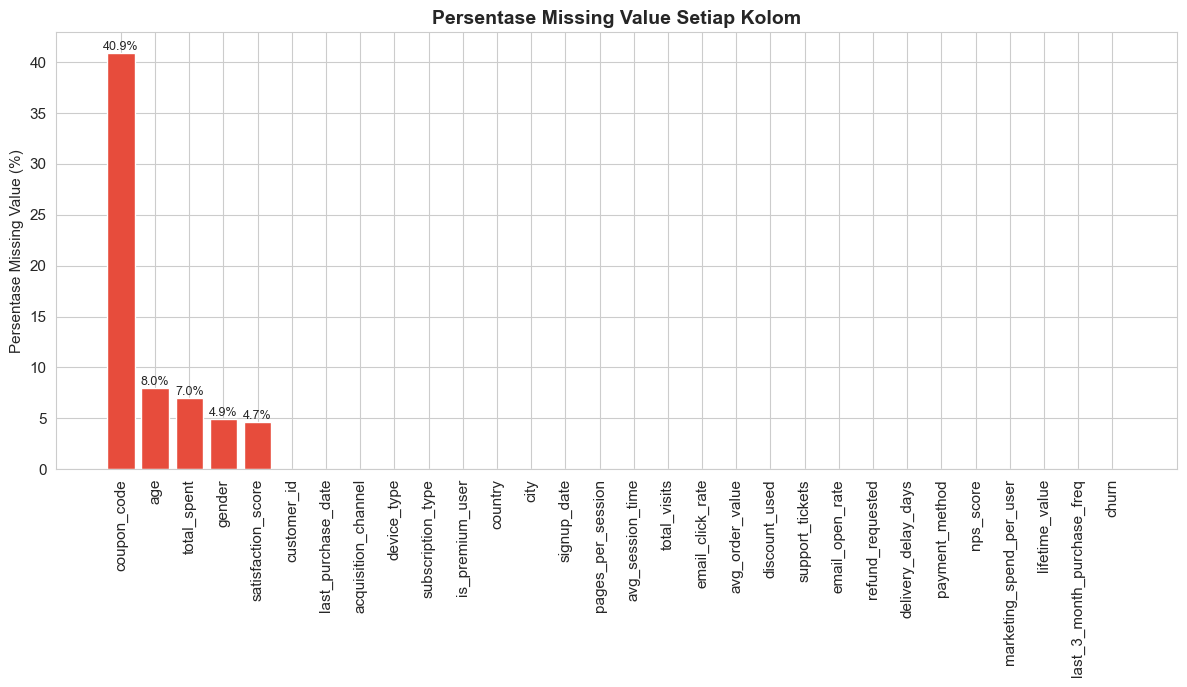

In [9]:
# Visualisasi: diagram batang persentase missing value
plt.figure(figsize=(12, 7))
missing_to_plot = missing_percent.sort_values(ascending=False)

colors = ['#e74c3c' if v > 0 else '#95a5a6' for v in missing_to_plot.values]
bars = plt.bar(range(len(missing_to_plot)), missing_to_plot.values, color=colors)

plt.xticks(range(len(missing_to_plot)), missing_to_plot.index, rotation=90)
plt.ylabel('Persentase Missing Value (%)')
plt.title('Persentase Missing Value Setiap Kolom', fontsize=14, fontweight='bold')

# Tambah label di atas bar yang ada missing
for i, (idx, val) in enumerate(missing_to_plot.items()):
    if val > 0:
        plt.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 1.7 Distribusi Variabel Target (Churn)
Cek apakah dataset balanced atau imbalanced.

In [10]:
# Distribusi target churn
churn_counts = df['churn'].value_counts()
churn_percent = df['churn'].value_counts(normalize=True) * 100

print("Distribusi kelas Churn:")
print(f"  - Tidak Churn (0): {churn_counts[0]} ({churn_percent[0]:.2f}%)")
print(f"  - Churn (1)      : {churn_counts[1]} ({churn_percent[1]:.2f}%)")
print(f"\nRasio: {churn_counts[0]/churn_counts[1]:.2f} : 1")

Distribusi kelas Churn:
  - Tidak Churn (0): 12702 (84.68%)
  - Churn (1)      : 2298 (15.32%)

Rasio: 5.53 : 1


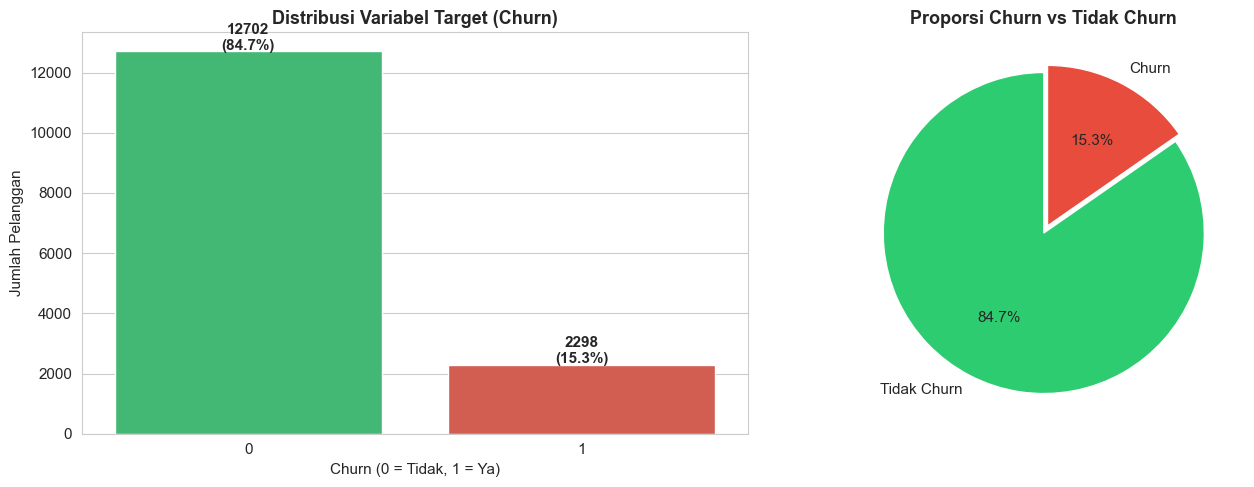

In [11]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.countplot(x='churn', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribusi Variabel Target (Churn)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn (0 = Tidak, 1 = Ya)')
axes[0].set_ylabel('Jumlah Pelanggan')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v}\n({churn_percent[i]:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Tidak Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Proporsi Churn vs Tidak Churn', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 1.8 Heatmap Korelasi Fitur Numerik
Identifikasi hubungan antar variabel yang berpotensi mempengaruhi churn.

In [12]:
# Pilih hanya kolom numerik untuk korelasi
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Buang customer_id karena hanya ID, tidak informatif
if 'customer_id' in numeric_cols:
    numeric_cols.remove('customer_id')

corr_matrix = df[numeric_cols].corr()
print(f"Jumlah fitur numerik untuk korelasi: {len(numeric_cols)}")

Jumlah fitur numerik untuk korelasi: 19


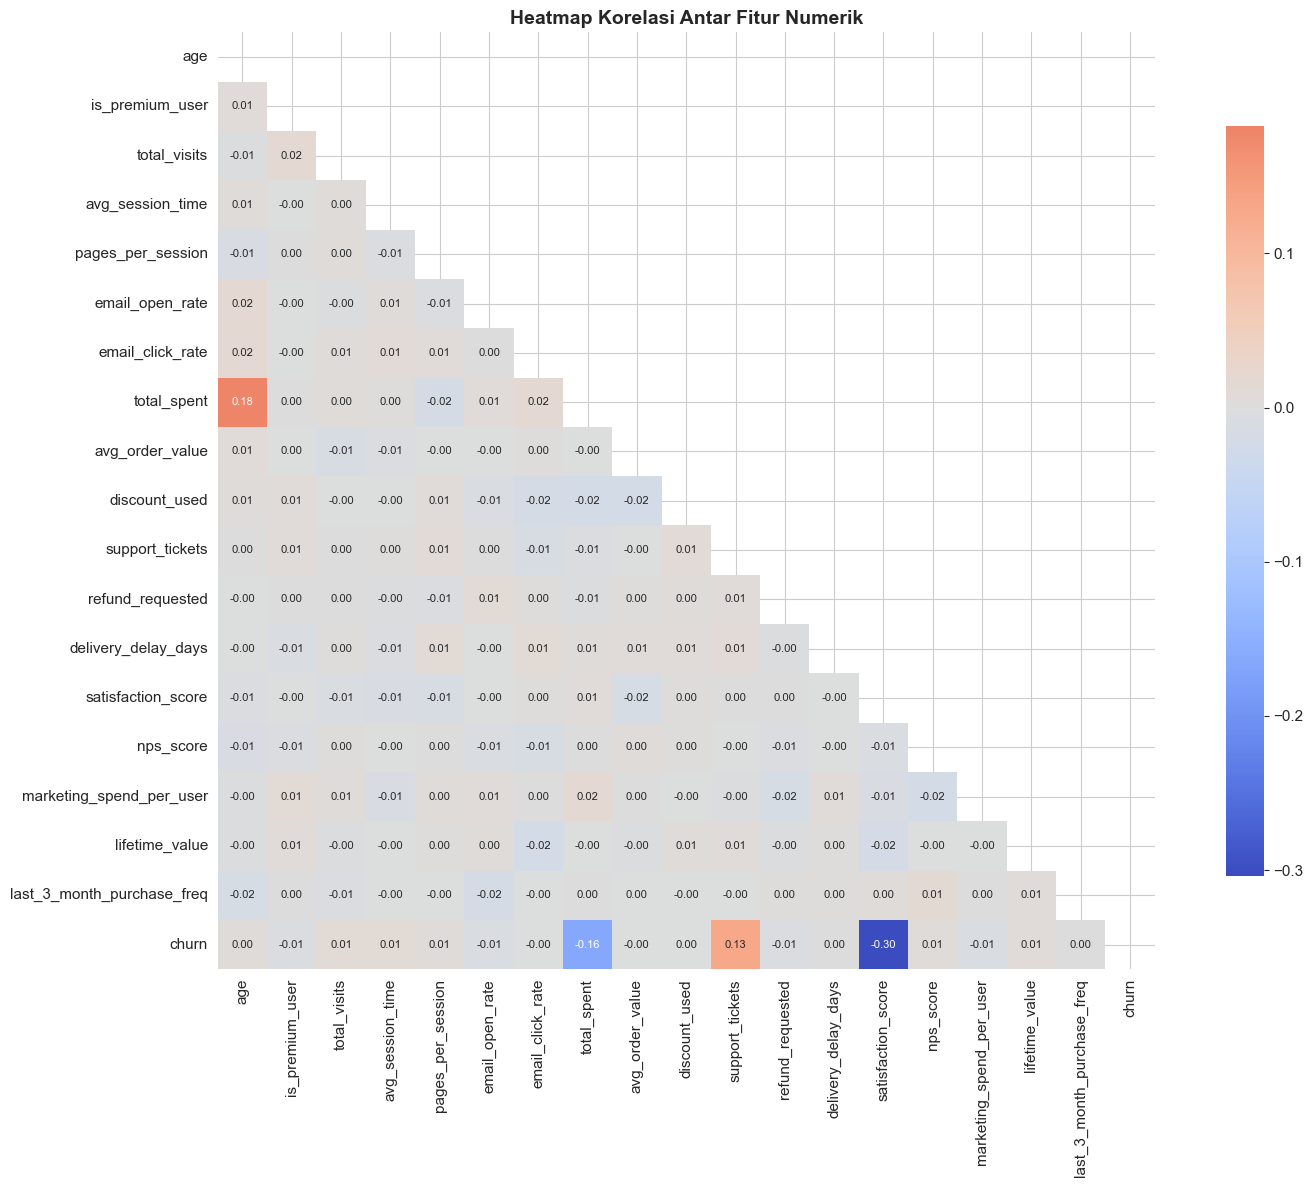

In [13]:
# Heatmap korelasi
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, mask=mask,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Top 10 fitur paling berkorelasi dengan CHURN:
satisfaction_score          0.303588
total_spent                 0.163279
support_tickets             0.127910
total_visits                0.013212
avg_session_time            0.012198
email_open_rate             0.008439
marketing_spend_per_user    0.007315
refund_requested            0.006959
lifetime_value              0.006250
pages_per_session           0.005871
Name: churn, dtype: float64


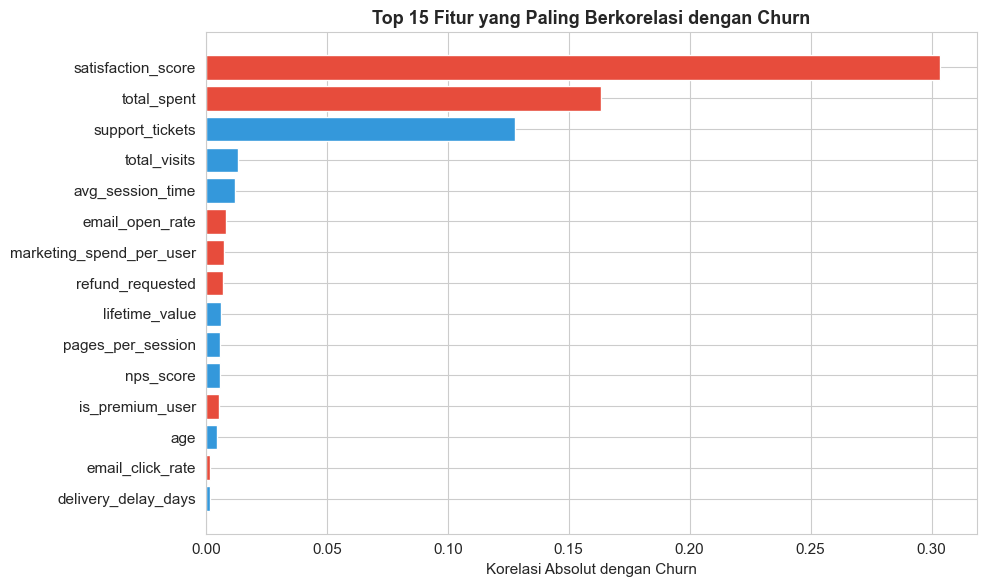

In [14]:
# Top 10 fitur dengan korelasi tertinggi terhadap CHURN
churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)

print("Top 10 fitur paling berkorelasi dengan CHURN:")
print(churn_corr.head(10))

# Visualisasi
plt.figure(figsize=(10, 6))
top_corr = churn_corr.head(15)
colors = ['#e74c3c' if corr_matrix['churn'][idx] < 0 else '#3498db' for idx in top_corr.index]
plt.barh(range(len(top_corr)), top_corr.values, color=colors)
plt.yticks(range(len(top_corr)), top_corr.index)
plt.xlabel('Korelasi Absolut dengan Churn')
plt.title('Top 15 Fitur yang Paling Berkorelasi dengan Churn', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 📝 Kesimpulan EDA (Minggu 1)

> **Tuliskan insight Anda di sini setelah menjalankan kode di atas**, contoh:
> 
> 1. **Bentuk Dataset:** 15.000 baris × 30 kolom (sesuai spesifikasi).
> 2. **Tipe Data:** Terdapat fitur numerik (int/float) dan kategorikal (object). Kolom tanggal (`signup_date`, `last_purchase_date`) berformat object dan perlu di-convert.
> 3. **Missing Value:** Beberapa kolom memiliki missing value yang perlu ditangani di tahap preprocessing.
> 4. **Keseimbangan Kelas:** Bergantung output — jika selisih > 70:30, dataset dikatakan imbalanced. Ini akan mempengaruhi pemilihan metrik (precision/recall lebih relevan dibanding accuracy saja).
> 5. **Korelasi:** Fitur dengan korelasi tertinggi terhadap churn akan menjadi fokus modeling.

---